In [10]:
import pandas as pd
df = pd.read_csv("C:\\Users\\user\\my_snippet\\PANDAS\\coffee_shop.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


<Axes: xlabel='hour'>

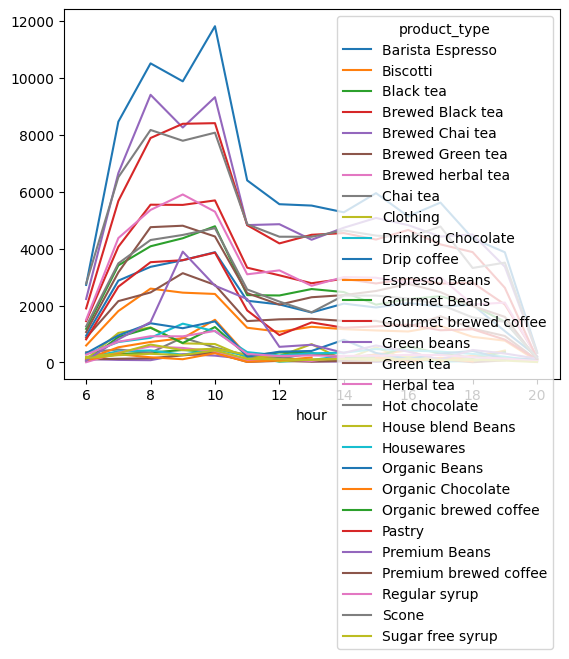

In [47]:

#basket size per transaction
mean_basket = df.groupby('transaction_id')['transaction_qty'].agg(['sum','mean'])

#most profitable product
most_profitable = df.groupby("product_type")['revenue'].sum().idxmax()

#STORE PERFORMANCE 
store_perf= df.groupby('store_location')['revenue'].agg(['sum','mean','max','min'])

#time-based demand
df['datetime'] = pd.to_datetime(df['transaction_date']+" " +df['transaction_time'],
                                format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.to_period('M')

monthly_trend = df.groupby('month')['revenue'].sum()

time_based_demand = df.groupby('hour')['product_type'].nunique()

hour_wise = df.groupby(['hour','product_type'])['revenue'].sum()

#top_prod 
top_prod = df.groupby(['store_location'])['product_type'].value_counts(ascending=False)
mean_basket
hour_wise.unstack().plot()

In [55]:
#improvement
store_perf = df.groupby('store_location').agg({
    'revenue': ['sum','mean'],
    'transaction_id': 'nunique'
})
store_performance = df.groupby('store_location').agg({
    'revenue':['sum','mean'],
    'transaction_id': 'nunique'
})
basket_size = df.groupby('transaction_id')['transaction_qty'].sum()
basket_size.mean()
df.groupby('product_type').agg({
    'revenue':'sum',
    'hour':'nunique',
    'transaction_qty':'mean',
    'unit_price':'mean',
    'product_category':'nunique'
})
top_prod = (
    df.groupby('store_location')['product_type']
    .value_counts()
    .groupby(level=0)
    .head(3)
)
top_prod
top = (df.groupby('store_location')['product_type']
       .value_counts()
       .groupby(level=0)
)      .head(3)
top
tmp = df.groupby('store_location')['product_type'].value_counts().reset_index(name='count')

top_prod = tmp.groupby('store_location').head(3)
tmp

,store_location,product_type,count
0,Astoria,Brewed Chai tea,6293
1,Astoria,Gourmet brewed coffee,6053
2,Astoria,Barista Espresso,4930
3,Astoria,Hot chocolate,4300
4,Astoria,Brewed herbal tea,4008
...,...,...,...
82,Lower Manhattan,Espresso Beans,77
83,Lower Manhattan,Green tea,73
84,Lower Manhattan,Herbal tea,67
85,Lower Manhattan,House blend Beans,48
